In [4]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

Image size (H,W) is: (256, 256, 3)


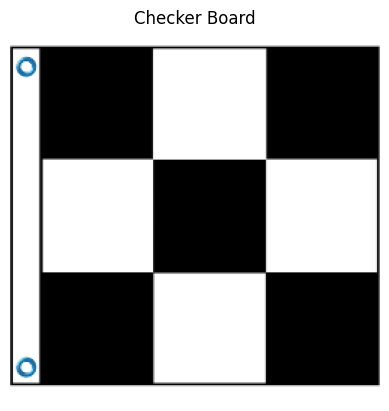

In [42]:
# Read and Display image in separate window

img = cv2.imread('checkersboard.png')
img_adj = cv2.resize(img,(256,256))
# print(img)
print("Image size (H,W) is:", img_adj.shape)
# cv2.imshow('Cat', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
plt.imshow(img_adj)
plt.title("Checker Board")
plt.axis('off')
plt.show()

(408, 612, 3)


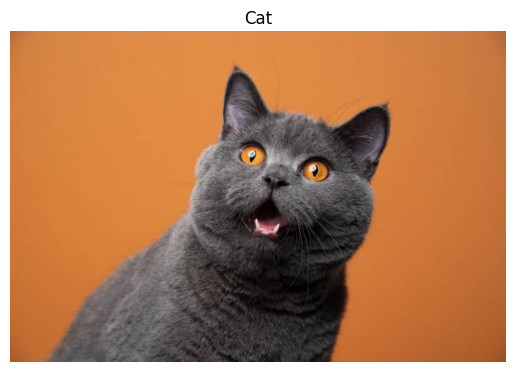

In [35]:
# Read and Display image

img = cv2.imread('cat.jpg')

# Convert the color channel order from BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img_rgb.shape)
plt.imshow(img_rgb)
plt.title("Cat")
plt.axis('off')
plt.show()

In [44]:
# Write an image

image = cv2.imread('Cat.jpg', 0)
cv2.imwrite('gray.jpg', image)

True

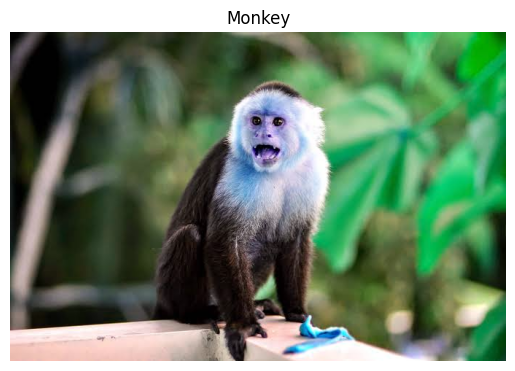

In [5]:
# Read an image

img = cv2.imread("monkey.jpg")
# cv2.imshow("window", img)
# cv2.waitKey(0)

b, g, r = cv2.split(img)

# print(type(img))
# print(img.shape)
# print(img.size)

plt.imshow(img)
plt.title("Monkey")
plt.axis('off')
plt.show()

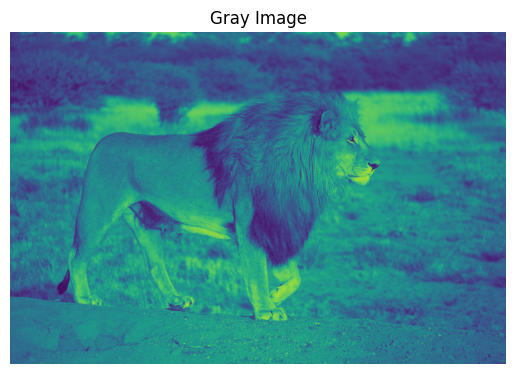

In [37]:
# Converting RGB image to Grayscale

img = cv2.imread("lion.jpg")
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# print(gray_img.shape)
# cv2.imshow("window", gray_img)
# cv2.waitKey(0)
plt.imshow(gray_img)
plt.axis('off')
plt.title("Gray Image")
plt.show()

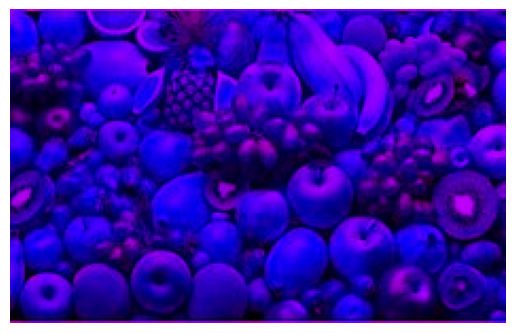

In [39]:
# BGR

img = cv2.imread("fruits.jpg")
# cv2.imshow("window", img)
img[:,:,1] = 0
# cv2.waitKey(0)
plt.imshow(img)
plt.axis('off')
plt.show()

(148, 702)


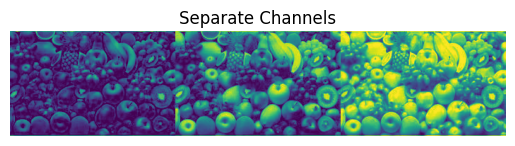

In [22]:
img = cv2.imread("fruits.jpg")
# cv2.imshow("window", img)
imgBlue = img[:,:,0] 
imgGreen = img[:,:,1]
imgRed = img[:,:,2] 
new_img = np.hstack((imgBlue, imgGreen, imgRed))
# img_resized = cv2.resize(new_img,(256, 256))
# cv2.imshow("window", new_img)
# cv2.waitKey(0)
print(new_img.shape)
plt.imshow(new_img)
plt.title("Separate Channels")
plt.axis('off')
plt.show()

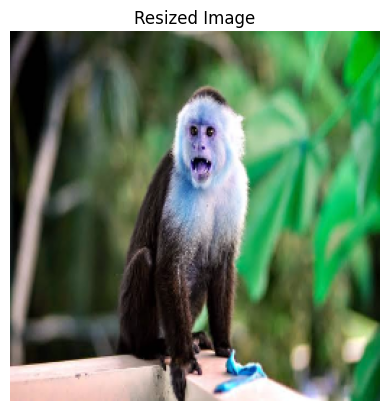

In [47]:
# Resizing an Image

img = cv2.imread("monkey.jpg")
img_resize = cv2.resize(img,(256,256))
# cv2.imshow(img_resize)
# cv2.waitKey(0)
# print(img_resize.shape)
plt.imshow(img_resize)
plt.title("Resized Image")
plt.axis('off')
plt.show()

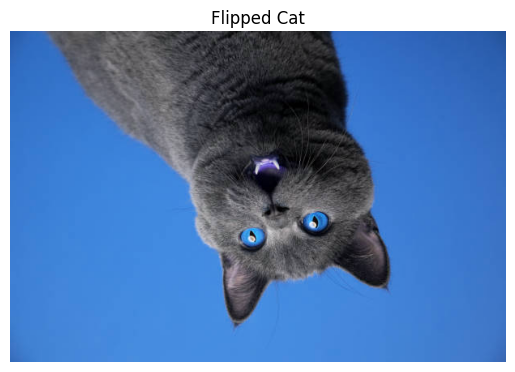

In [53]:
# Flipping an Image

img = cv2.imread("cat.jpg")
img_flip = cv2.flip(img, 0)
plt.imshow(img_flip)
plt.title("Flipped Cat")
plt.axis('off')
plt.show()

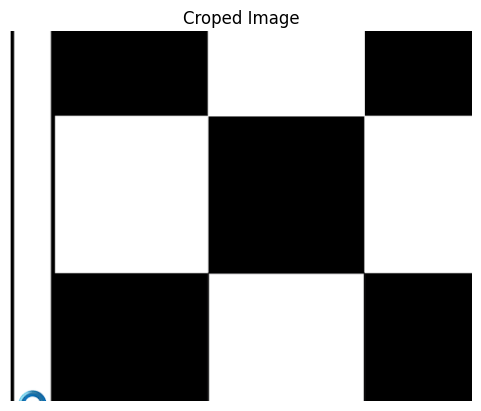

In [66]:
# Cropping an Image

img = cv2.imread("checkersboard.png")
crop_img = img[100:500, 0:500]
# print(img.shape)
plt.imshow(crop_img)
plt.title("Croped Image")
plt.axis('off')
plt.show()

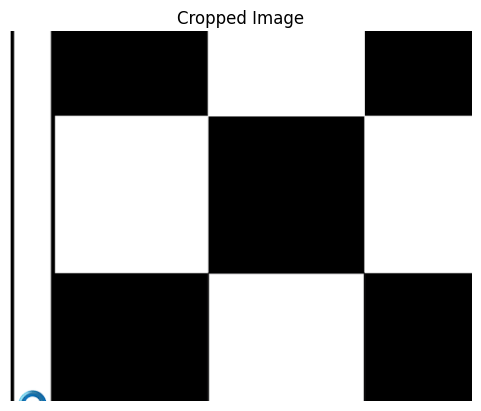

In [68]:
# Saving an Image
img = cv2.imread("checkersboard.png")
crop_img = img[100:500, 0:500]
cv2.imwrite("Cropped_Img.png", crop_img)
plt.imshow(crop_img)
plt.title("Cropped Image")
plt.axis('off')
plt.show()

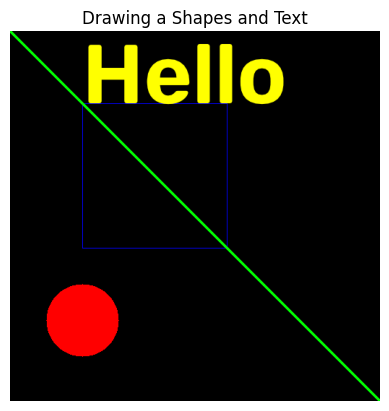

In [18]:
# Drawing Shapes and Text on Images

img = np.zeros((512, 512, 3), dtype=np.uint8)

# Rectangle
cv2.rectangle(img, (100, 100), (300, 300), color=(255, 0, 0), thickness=1)
# Circle
cv2.circle(img, (100, 400), radius=50, color=(0, 0, 255), thickness=-1)
# Line
cv2.line(img, (0,0), (512, 512), color=(0, 255, 0), thickness=2)
# Text
cv2.putText(img,
            org=(100,100),
            fontScale=4,
            color=(0, 255, 255),
            lineType=cv2.LINE_AA,
            text="Hello",
            fontFace=cv2.FONT_ITALIC,
            thickness=3)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Drawing a Shapes and Text")
plt.axis('off')
plt.show()

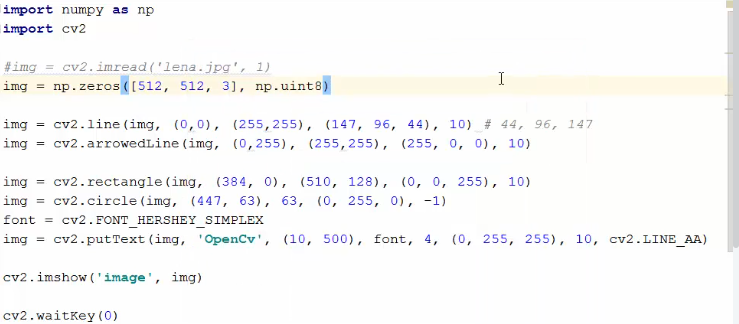

In [17]:
# Working with OpenCV Events

def draw(event, x, y, flags, params):
    if event == 2:
        cv2.circle(img, (x,y), radius=50, color=(0, 0, 255), thickness=-1)

cv2.namedWindow(winname = "window")
cv2.setMouseCallback("window", draw)

# img = np.zeros((512, 512, 3,), dtype=np.uint8)
img = cv2.imread("checkersboard.png")

while True:
    
   cv2.imshow("window", img)
   if cv2.waitKey(1) & 0xFF == ord('x'):
        break
cv2.destroyAllWindows()

In [3]:
# 1. Initialize state control variables (using 'drawing' to avoid conflict with OpenCV's flags)
drawing = False
ix, iy = -1, -1

# 2. Define the interactive mouse callback function
def draw_rectangle(event, x, y, flags, param):
    
    global ix, iy, drawing

    # Check for Left Button Down: Record starting coordinate and start drawing    
    if event == cv2.EVENT_LBUTTONDOWN:
        
        drawing = True
        ix = x
        iy = y
        
    # Check for Mouse Movement: Draw an updating shape ONLY if the button is held down
    elif event == cv2.EVENT_MOUSEMOVE:
       if drawing == True:
         # Tip: To prevent a trailing path of boxes, you can optionally refresh the image here
        cv2.rectangle(img, (ix, iy), (x,y), color=(0, 255, 255), thickness=-1)

    # Check for Left Button Up: Stop the drawing state machine
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        cv2.rectangle(img, (ix, iy), (x,y), color=(0, 255, 255), thickness=-1)


# 3. Initialize your display workspace canvas
img = np.zeros((512, 512, 3), dtype=np.uint8)
cv2.namedWindow(winname="window")

# 4. Bind the listener function to your specific window layout
cv2.setMouseCallback("window", draw_rectangle)

# 5. Continuous rendering display loop
while True:
    
   cv2.imshow("window", img)

   # Exits the application window smoothly if 'x' key is tapped on keyboard
   if cv2.waitKey(1) & 0xFF == ord('x'):
        break

# 6. Clean up computer memory blocks completely upon close
cv2.destroyAllWindows()